## Checking Device

In [29]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count :", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name     :", torch.cuda.get_device_name(0))

CUDA available: True
Device count : 1
GPU name     : NVIDIA GeForce RTX 4070


## Getting BBCA Data

In [30]:
import yfinance as yf
symbol = "BBCA.JK"

print(f"Downloading data for {symbol}...")


df = yf.download(
    symbol,
    start="2020-05-15",
    end="2025-05-15",
    interval="1d"
)

print(df.head())
df.to_csv("./datasets/bbca.csv")

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open     Volume
Ticker          BBCA.JK      BBCA.JK      BBCA.JK      BBCA.JK    BBCA.JK
Date                                                                     
2020-05-15  4031.091553  4208.004662  3942.634998  4144.821408  205790000
2020-05-18  4014.241943  4081.637401  4001.605295  4043.727456  139997500
2020-05-19  3942.635010  4178.519156  3942.635010  4077.425950  128504500
2020-05-20  4014.241943  4043.727456  3951.058702  3976.331998  119158000
2020-05-26  4186.943848  4212.217151  4022.667379  4022.667379  176076500


## Plot Close Price

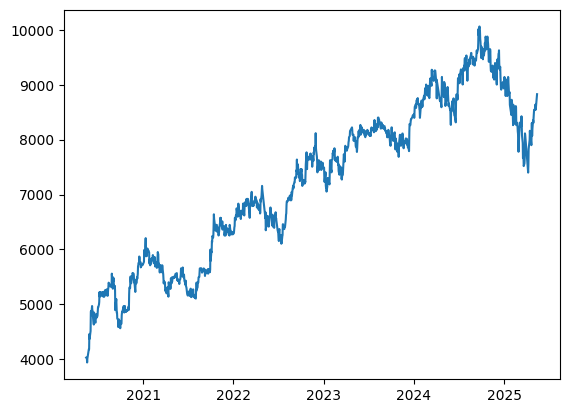

In [31]:
import matplotlib.pyplot as plt

plt.plot(df['Close'])
plt.show()

## Pre-Processing Data

In [32]:
data = df[['Close']].copy()

In [33]:
data.dropna(inplace=True)

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

Menentukan X, y. X=Window 30 data; y=Nilai setelah 30 data sebelumnya

In [35]:
import numpy as np

window_size = 30

X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1170, 30)
y shape: (1170,)


## Splitting Data

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)
print(f"Length Train Data: {len(X_train)}")
print(f"Length Test Data: {len(X_test)}")

Length Train Data: 936
Length Test Data: 234


## Training using SVR

In [37]:
from sklearn.svm import SVR

model = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.01
)

print("Training model...")
model.fit(X_train, y_train)
print("Training complete!")

Training model...
Training complete!


In [38]:
predictions = model.predict(X_test) 

In [39]:
# Rescale predictions
predictions = scaler.inverse_transform(
    predictions.reshape(-1, 1)
)

# Rescale y_actual
y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

In [40]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mse = mean_squared_error(y_test_actual, predictions)
mae = mean_absolute_error(y_test_actual, predictions)

print("\n===== EVALUATION =====")
print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")


===== EVALUATION =====
MSE : 29749.7635
MAE : 134.0755


In [41]:
correct = 0

for i in range(1, len(y_test_actual)):

    actual_diff = y_test_actual[i] - y_test_actual[i - 1]
    pred_diff = predictions[i] - y_test_actual[i - 1]

    if actual_diff * pred_diff > 0:
        correct += 1


dstat = correct / (len(y_test_actual) - 1)

print(f"Dstat : {dstat:.4f}")

Dstat : 0.5494


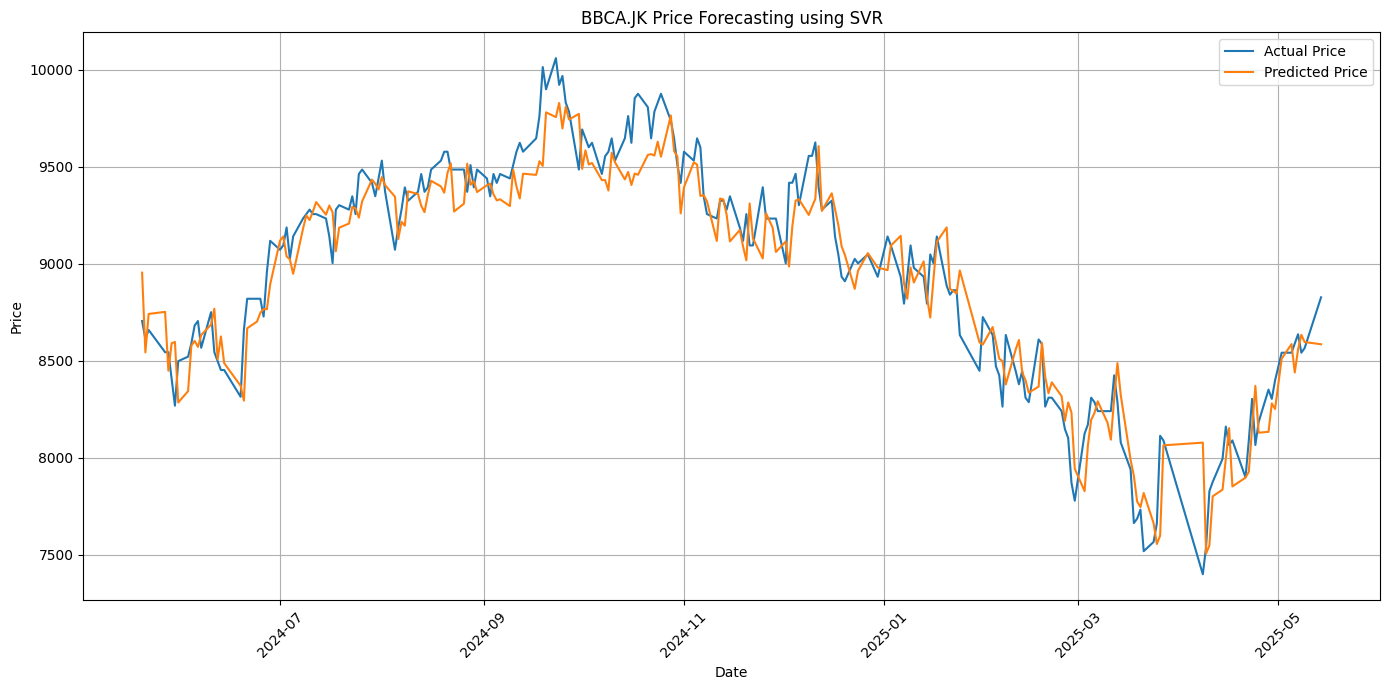

In [42]:
# ambil date setelah sliding window
dates = data.index[window_size:]

# split date sesuai train/test split
dates_train = dates[:len(X_train)]
dates_test = dates[len(X_train):]

plt.figure(figsize=(14, 7))

plt.plot(
    dates_test,
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    dates_test,
    predictions,
    label='Predicted Price'
)

plt.title(f'{symbol} Price Forecasting using SVR')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [43]:
import pandas as pd

future_days = 30

# ambil 30 data terakhir
last_window = scaled_data[-window_size:]

future_predictions = []
future_dates = pd.date_range(
    start=data.index[-1],
    periods=future_days + 1,
    freq='B'
)[1:]


current_window = last_window.copy()
for _ in range(future_days):
    
    pred = model.predict(
        current_window.reshape(1, -1)
    )

    future_predictions.append(pred[0])

    current_window = np.append(
        current_window[1:],
        [[pred[0]]],
        axis=0
    )


# Inverse transform
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

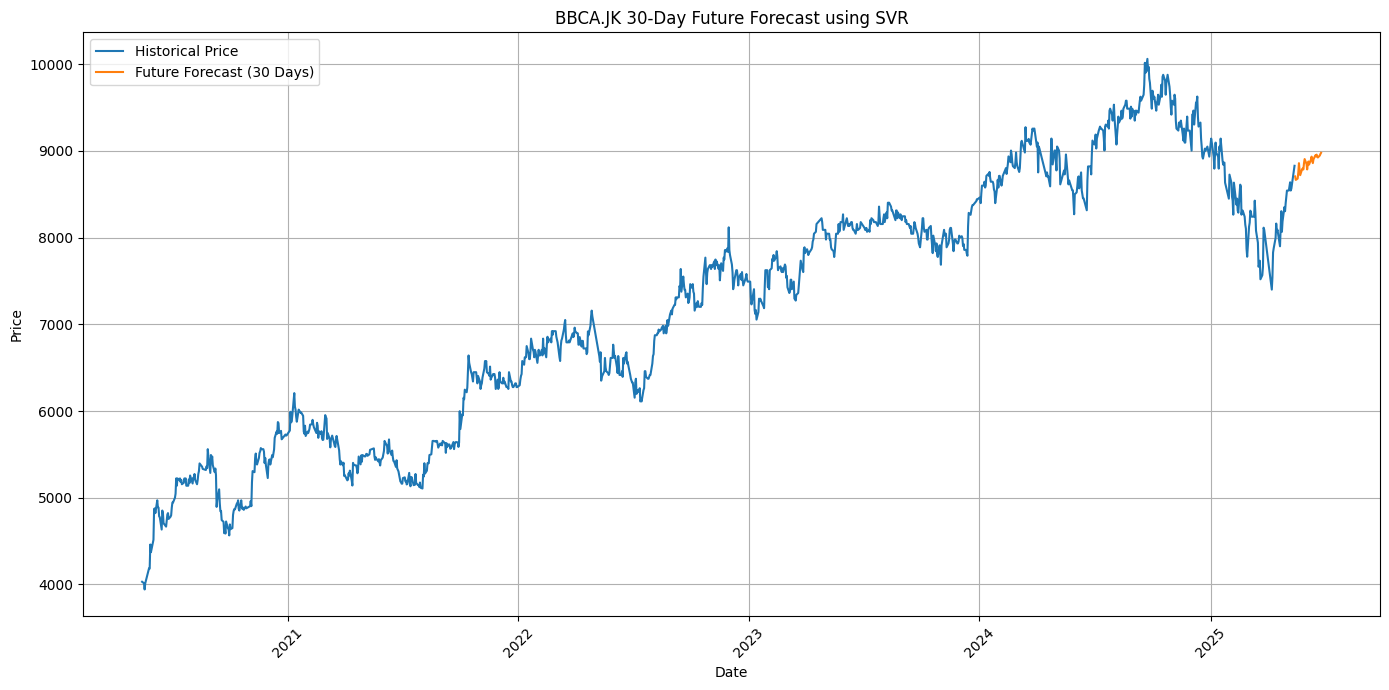

In [44]:
plt.figure(figsize=(14, 7))

plt.plot(
    data.index,
    data.values,
    label='Historical Price'
)

plt.plot(
    future_dates,
    future_predictions,
    label='Future Forecast (30 Days)'
)

plt.title(f'{symbol} 30-Day Future Forecast using SVR')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


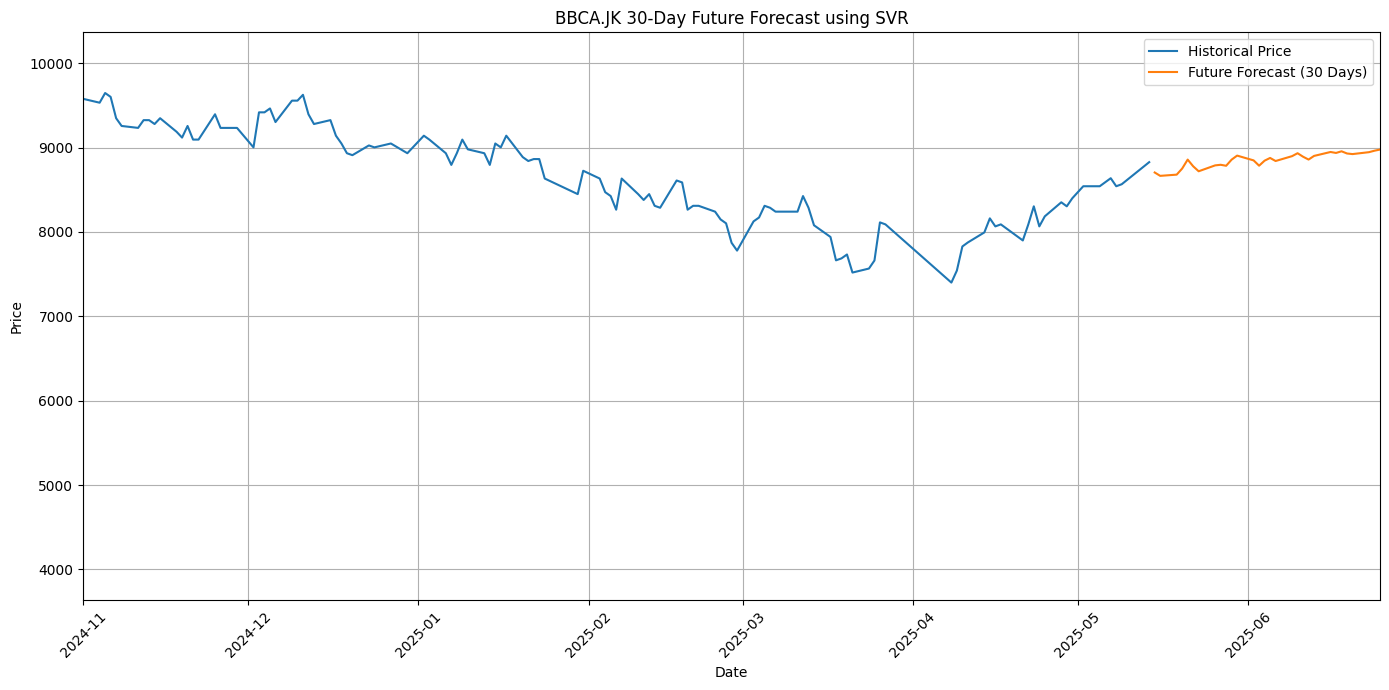

In [45]:
plt.figure(figsize=(14, 7))

plt.plot(
    data.index,
    data.values,
    label='Historical Price'
)

plt.plot(
    future_dates,
    future_predictions,
    label='Future Forecast (30 Days)'
)

plt.title(f'{symbol} 30-Day Future Forecast using SVR')

plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.grid(True)

plt.xlim(
    data.index[-120],
    future_dates[-1]
)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [46]:

print("\n===== 30 DAY FORECAST =====")
for i, value in enumerate(future_predictions):
    print(f"Day {i+1}: {value[0]:.2f}")


===== 30 DAY FORECAST =====
Day 1: 8705.19
Day 2: 8665.23
Day 3: 8679.57
Day 4: 8751.84
Day 5: 8857.93
Day 6: 8778.69
Day 7: 8719.51
Day 8: 8789.38
Day 9: 8796.51
Day 10: 8784.75
Day 11: 8857.68
Day 12: 8905.29
Day 13: 8848.56
Day 14: 8785.80
Day 15: 8845.32
Day 16: 8877.42
Day 17: 8841.24
Day 18: 8898.82
Day 19: 8933.55
Day 20: 8892.08
Day 21: 8858.31
Day 22: 8901.56
Day 23: 8948.17
Day 24: 8936.78
Day 25: 8956.38
Day 26: 8930.32
Day 27: 8923.30
Day 28: 8945.99
Day 29: 8963.38
Day 30: 8977.05


## Comparison with 5-10 other assets (Using BBCA Dataset Model)

| Asset        | Jenis           | Ticker    |
| ------------ | --------------- | --------- |
| BBCA         | Saham Indonesia | `BBCA.JK` |
| TLKM         | Saham Indonesia | `TLKM.JK` |
| AAPL         | Saham US        | `AAPL`    |
| NVDA         | Saham AI        | `NVDA`    |
| Bitcoin      | Crypto          | `BTC-USD` |
| Ethereum     | Crypto          | `ETH-USD` |
| Gold Futures | Komoditas       | `GC=F`    |


In [47]:
test_symbols = [
    "TLKM.JK",
    "AAPL",
    "NVDA",
    "BTC-USD",
    "ETH-USD",
    "GC=F"
]

[*********************100%***********************]  1 of 1 completed


===== TESTING TLKM.JK =====
MSE   : 481532.5907
MAE   : 656.3664
Dstat : 0.4467


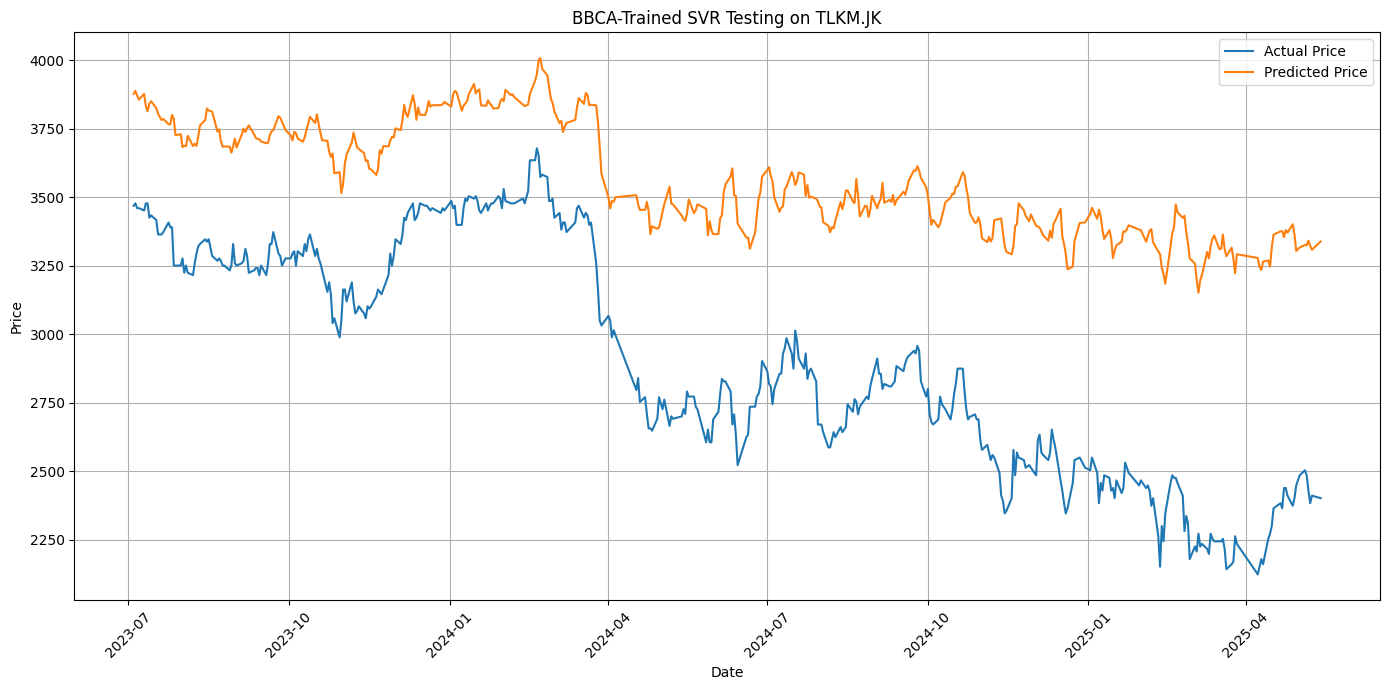

[*********************100%***********************]  1 of 1 completed


===== TESTING AAPL =====
MSE   : 11365325.7639
MAE   : 3371.0527
Dstat : 0.5499


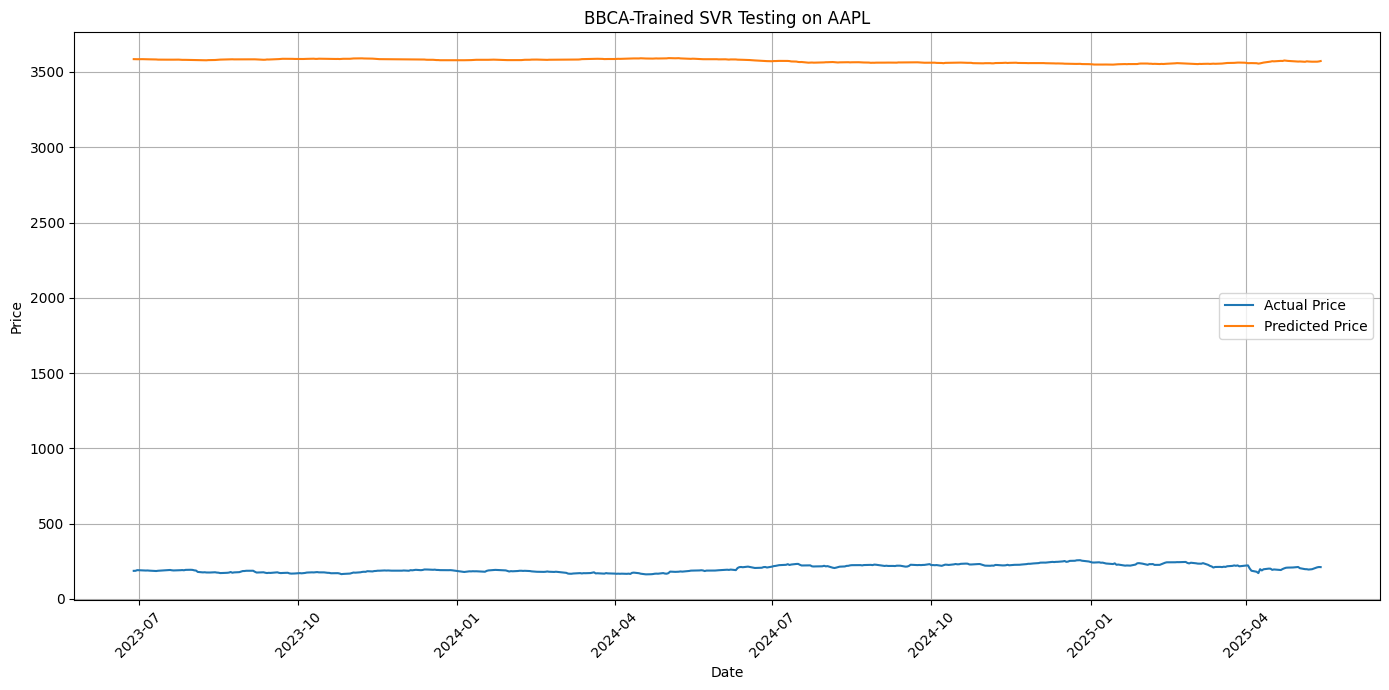

[*********************100%***********************]  1 of 1 completed


===== TESTING NVDA =====
MSE   : 12532471.2166
MAE   : 3539.6776
Dstat : 0.5499


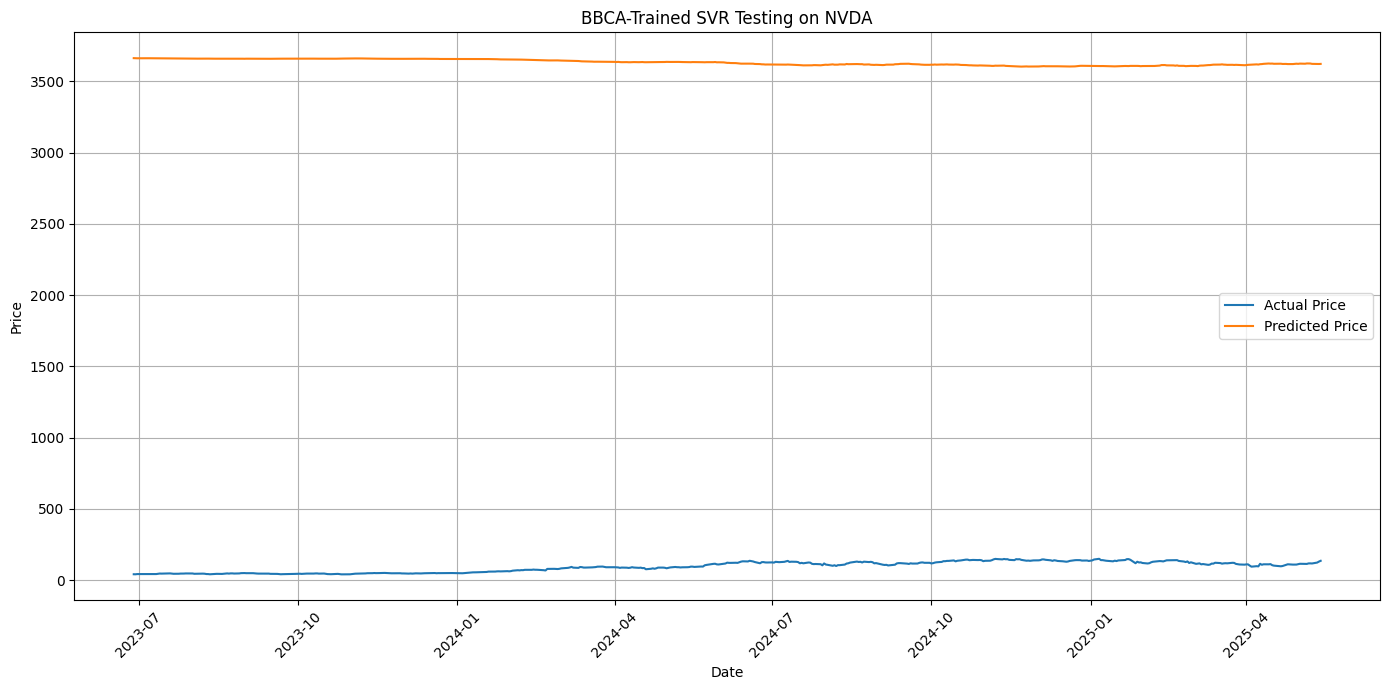

[*********************100%***********************]  1 of 1 completed


===== TESTING BTC-USD =====
MSE   : 3676665722.8339
MAE   : 55662.6672
Dstat : 0.4871


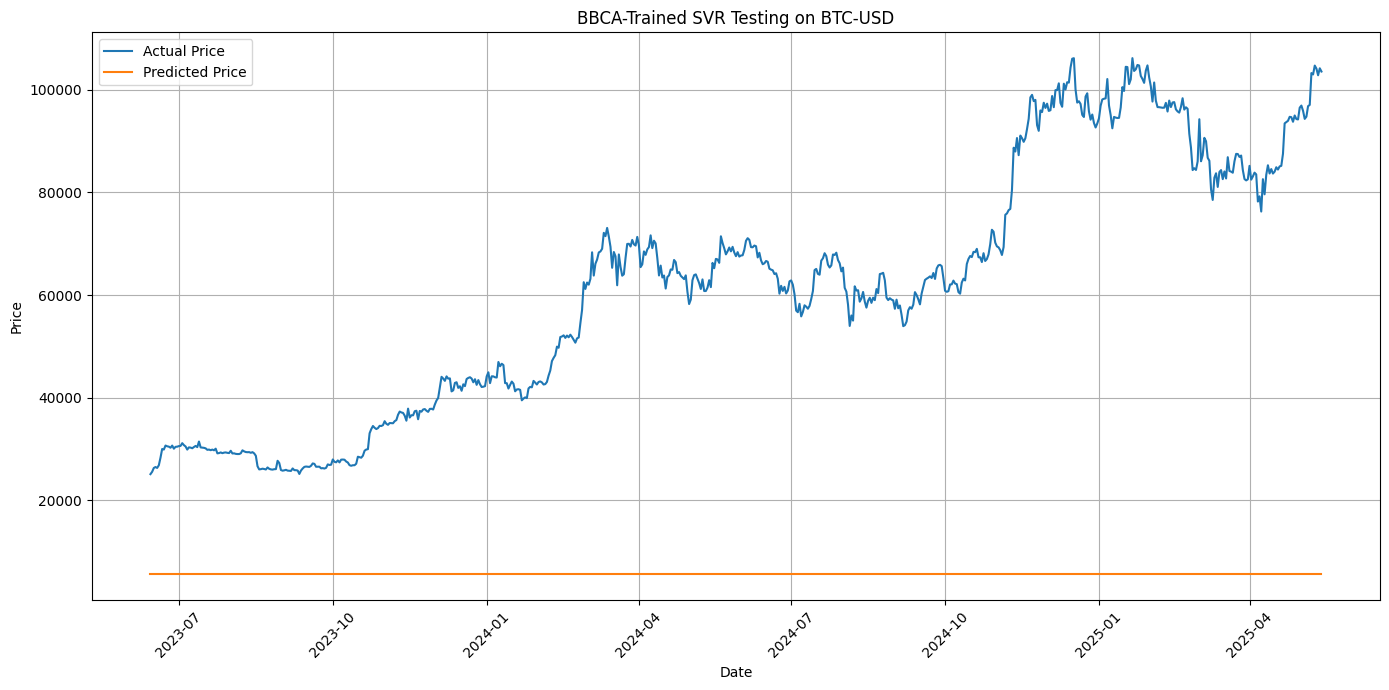

[*********************100%***********************]  1 of 1 completed


===== TESTING ETH-USD =====
MSE   : 992335.9116
MAE   : 889.8930
Dstat : 0.5114


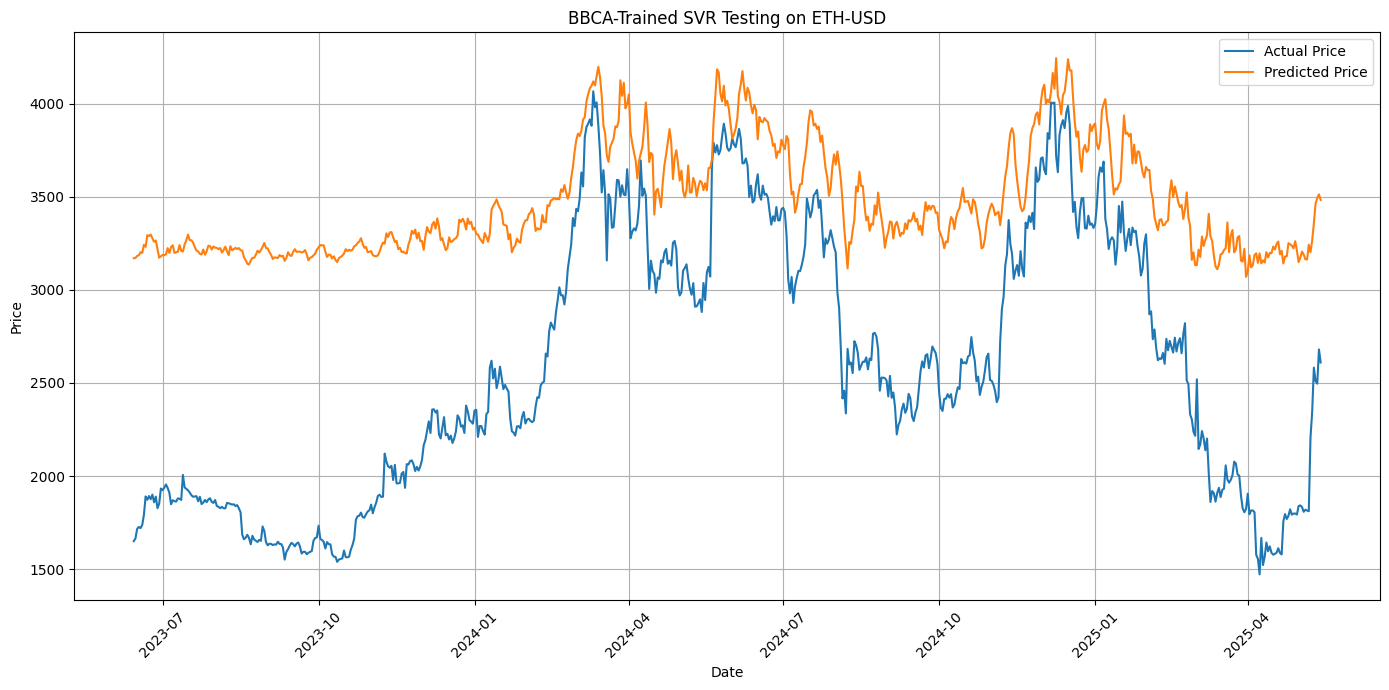

[*********************100%***********************]  1 of 1 completed


===== TESTING GC=F =====
MSE   : 1025804.4911
MAE   : 977.8510
Dstat : 0.5593


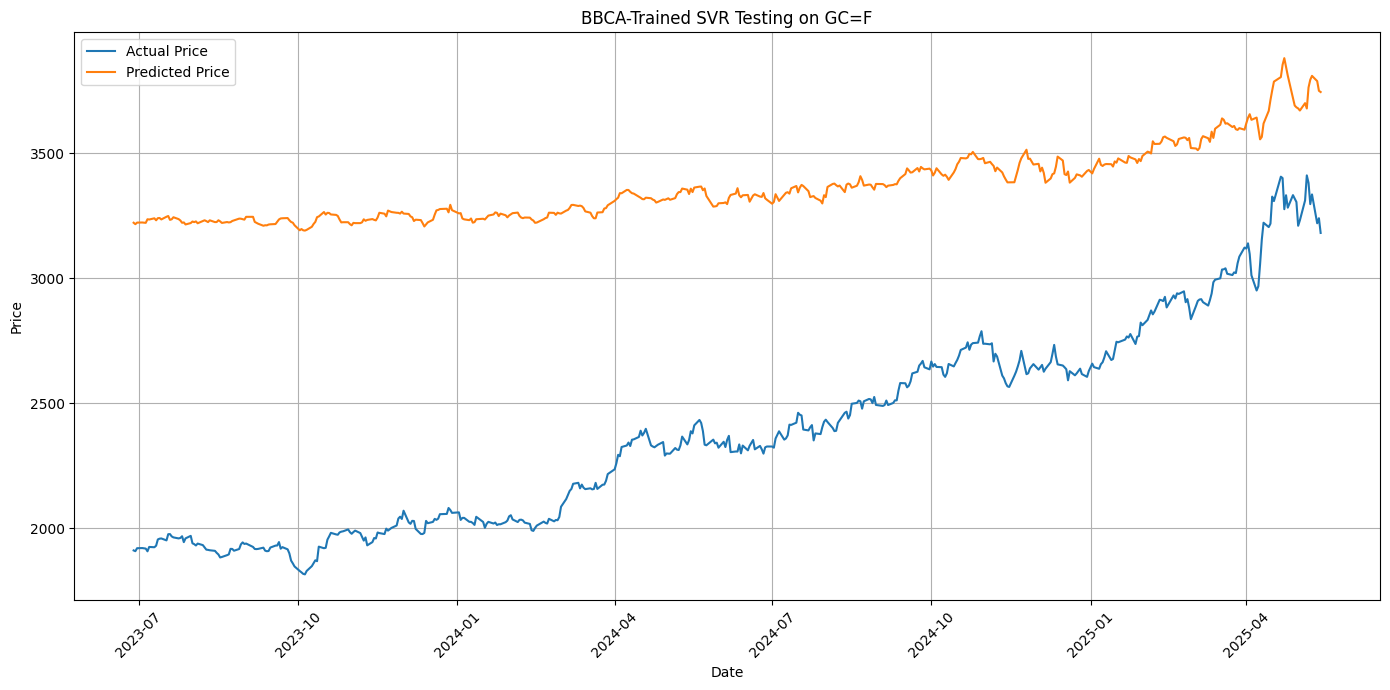

In [48]:
import yfinance as yf

results = []

for symbol in test_symbols:

    print(f"\n===== TESTING {symbol} =====")

    # Download test data
    df_test = yf.download(
        symbol,
        start="2023-05-15",
        end="2025-05-15",
        interval="1d"
    )

    test_data = df_test[['Close']].copy()

    # IMPORTANT:
    # gunakan scaler dari BBCA
    scaled_test = scaler.transform(test_data)

    # Build sliding window
    X_test = []
    y_test = []

    for i in range(window_size, len(scaled_test)):

        X_test.append(
            scaled_test[i-window_size:i, 0]
        )

        y_test.append(
            scaled_test[i, 0]
        )

    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # Predict menggunakan model BBCA
    predictions = model.predict(X_test)

    # Balik ke harga asli
    predictions = scaler.inverse_transform(
        predictions.reshape(-1, 1)
    )

    y_test_actual = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    )
    
    # Metrics
    mse = mean_squared_error(
        y_test_actual,
        predictions
    )
    
    mae = mean_absolute_error(
        y_test_actual,
        predictions
    )
    
    # DSTAT
    correct = 0
    
    for i in range(1, len(y_test_actual)):
    
        actual_diff = (
            y_test_actual[i] -
            y_test_actual[i - 1]
        )
    
        pred_diff = (
            predictions[i] -
            y_test_actual[i - 1]
        )
    
        if actual_diff * pred_diff > 0:
            correct += 1
    
    dstat = correct / (len(y_test_actual) - 1)
    
     # Save results
    results.append({
        "Symbol": symbol,
        "MSE": mse,
        "MAE": mae,
        "Dstat": dstat
    })
    
    print(f"MSE   : {mse:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"Dstat : {dstat:.4f}")

    dates_test = test_data.index[window_size:]

    plt.figure(figsize=(14, 7))
    
    plt.plot(
        dates_test,
        y_test_actual,
        label='Actual Price'
    )
    
    plt.plot(
        dates_test,
        predictions,
        label='Predicted Price'
    )
    
    plt.title(
        f'BBCA-Trained SVR Testing on {symbol}'
    )
    
    plt.xlabel('Date')
    plt.ylabel('Price')
    
    plt.legend()
    
    plt.grid(True)
    
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    
    plt.show()

## Comparison with 5-10 other assets (Retraining Model)

| Asset        | Jenis           | Ticker    |
| ------------ | --------------- | --------- |
| BBCA         | Saham Indonesia | `BBCA.JK` |
| TLKM         | Saham Indonesia | `TLKM.JK` |
| AAPL         | Saham US        | `AAPL`    |
| NVDA         | Saham AI        | `NVDA`    |
| Bitcoin      | Crypto          | `BTC-USD` |
| Ethereum     | Crypto          | `ETH-USD` |
| Gold Futures | Komoditas       | `GC=F`    |


In [49]:
symbols = [
    "BBCA.JK",
    "TLKM.JK",
    "AAPL",
    "NVDA",
    "BTC-USD",
    "ETH-USD",
    "GC=F"
]
print(symbols)

['BBCA.JK', 'TLKM.JK', 'AAPL', 'NVDA', 'BTC-USD', 'ETH-USD', 'GC=F']


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


===== BBCA.JK =====
MSE   : 29749.7635
MAE   : 134.0755
Dstat : 0.5494

===== TLKM.JK =====



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

MSE   : 3668.0705
MAE   : 47.3704
Dstat : 0.4592

===== AAPL =====
MSE   : 214.1445
MAE   : 12.4668
Dstat : 0.4286

===== NVDA =====
MSE   : 4223.6107
MAE   : 58.0374
Dstat : 0.4735



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



===== BTC-USD =====
MSE   : 13430027.2493
MAE   : 2664.2467
Dstat : 0.4930

===== ETH-USD =====


[*********************100%***********************]  1 of 1 completed

MSE   : 12860.6441
MAE   : 79.7686
Dstat : 0.5348

===== GC=F =====
MSE   : 155860.9614
MAE   : 253.7906
Dstat : 0.4449


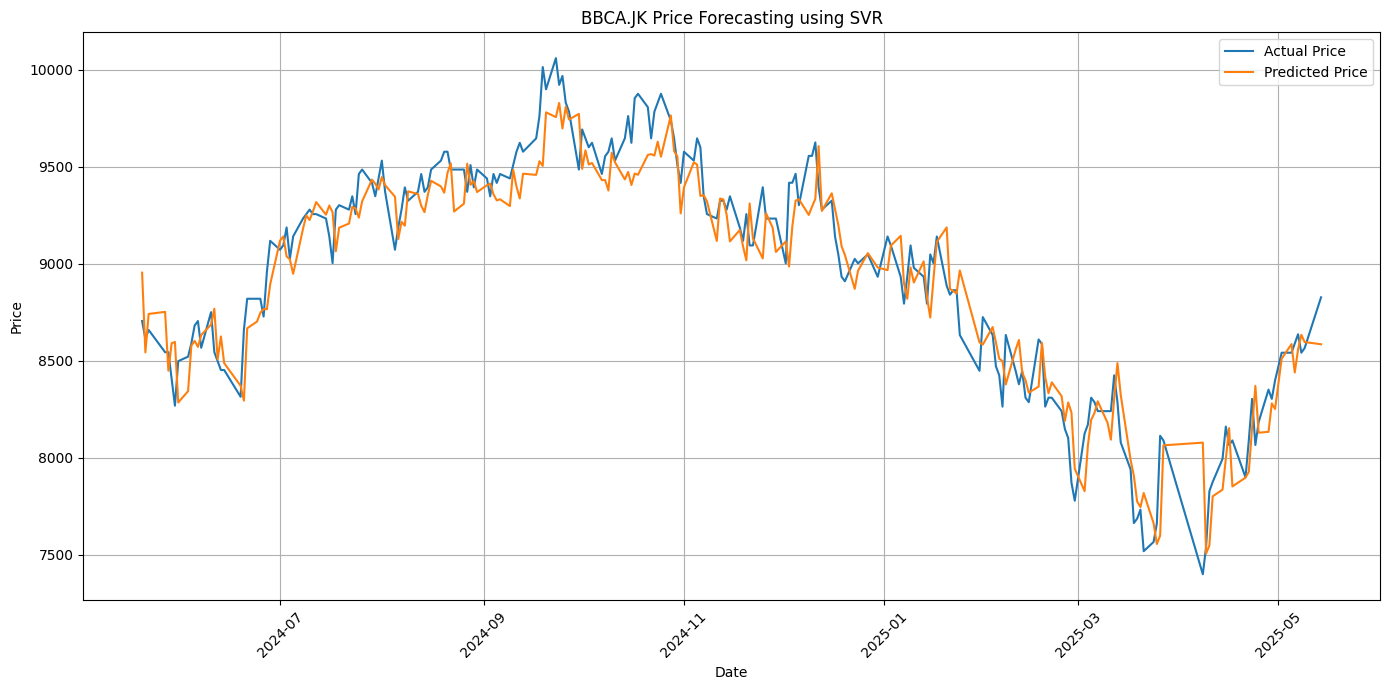

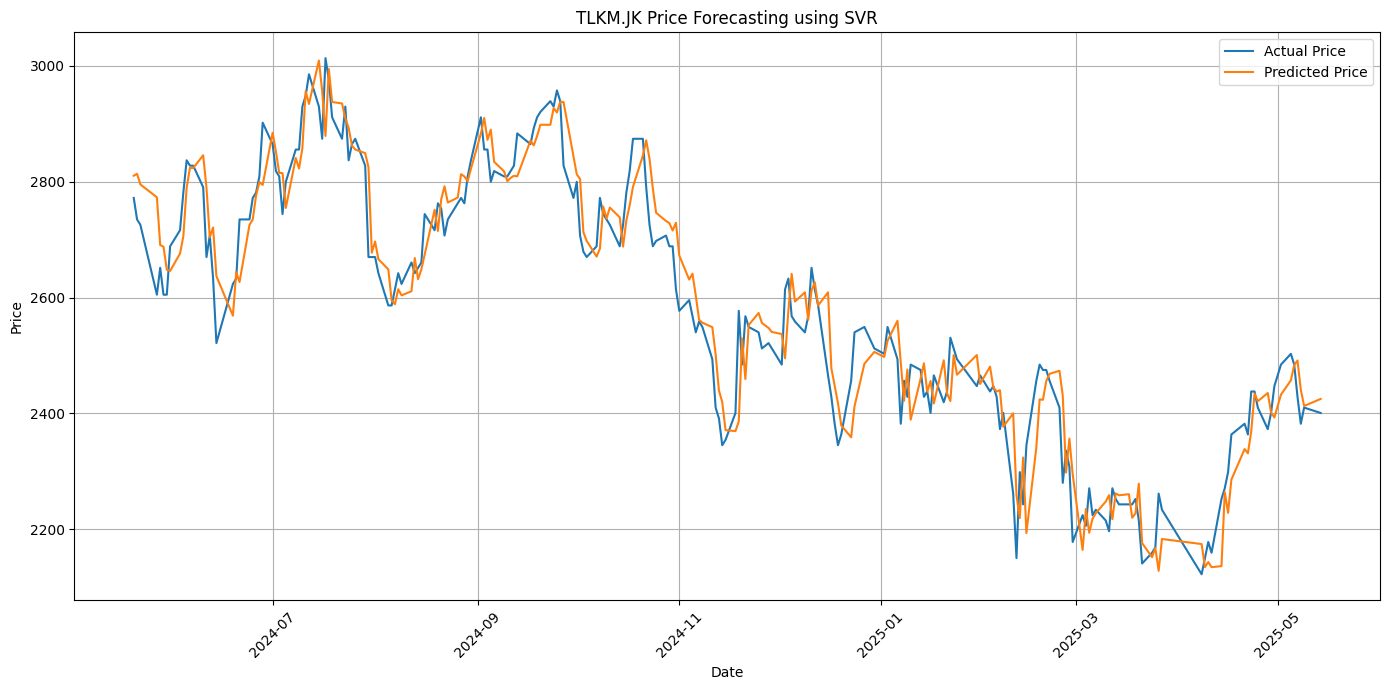

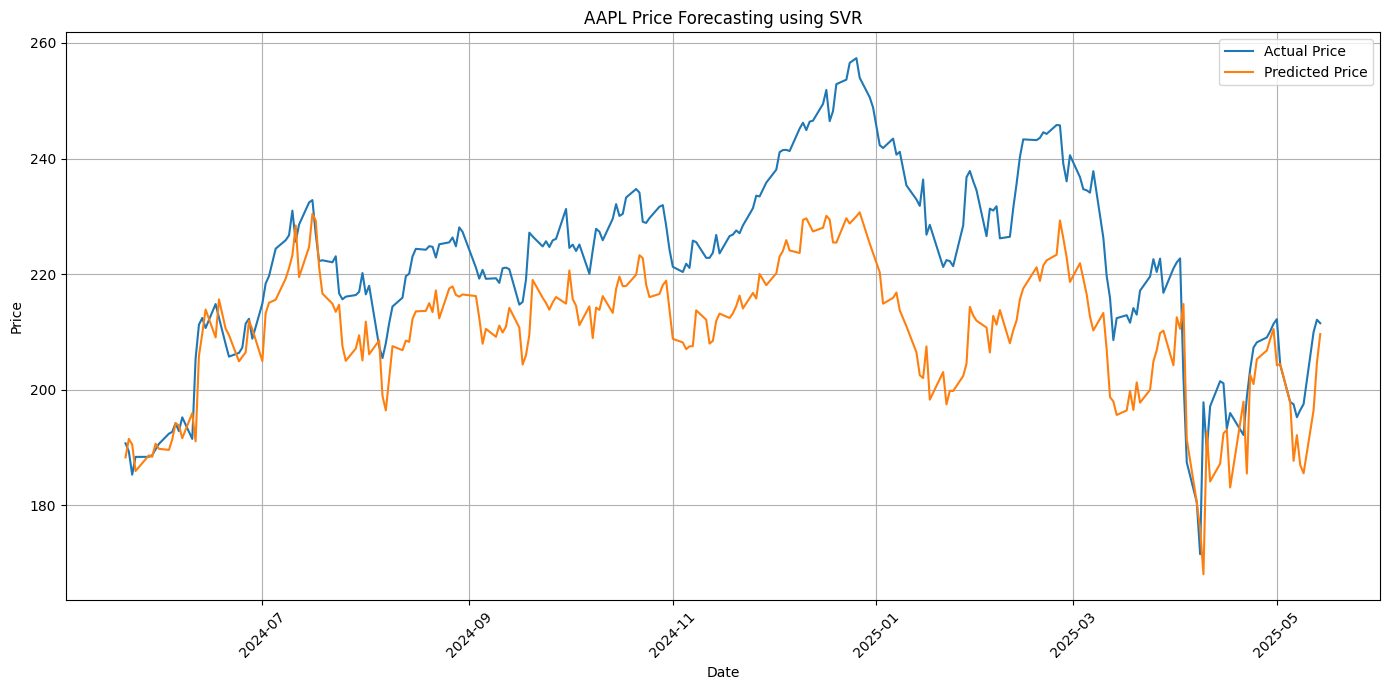

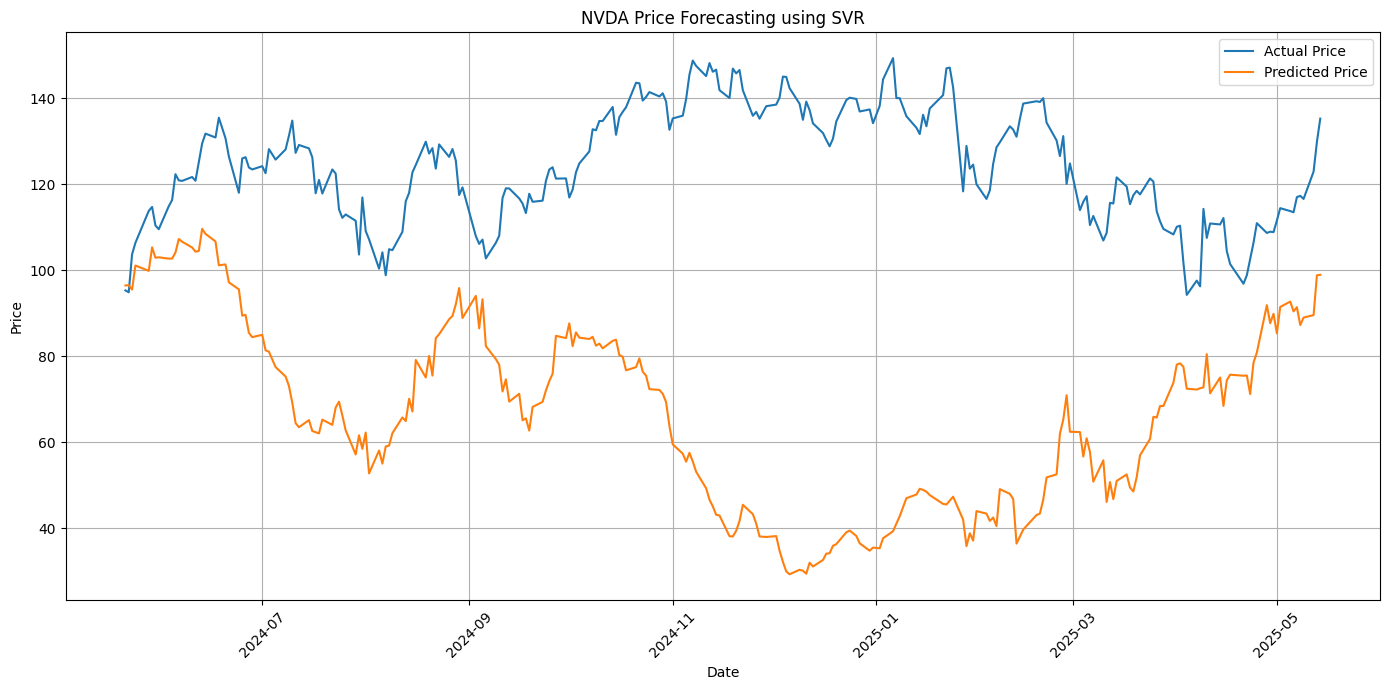

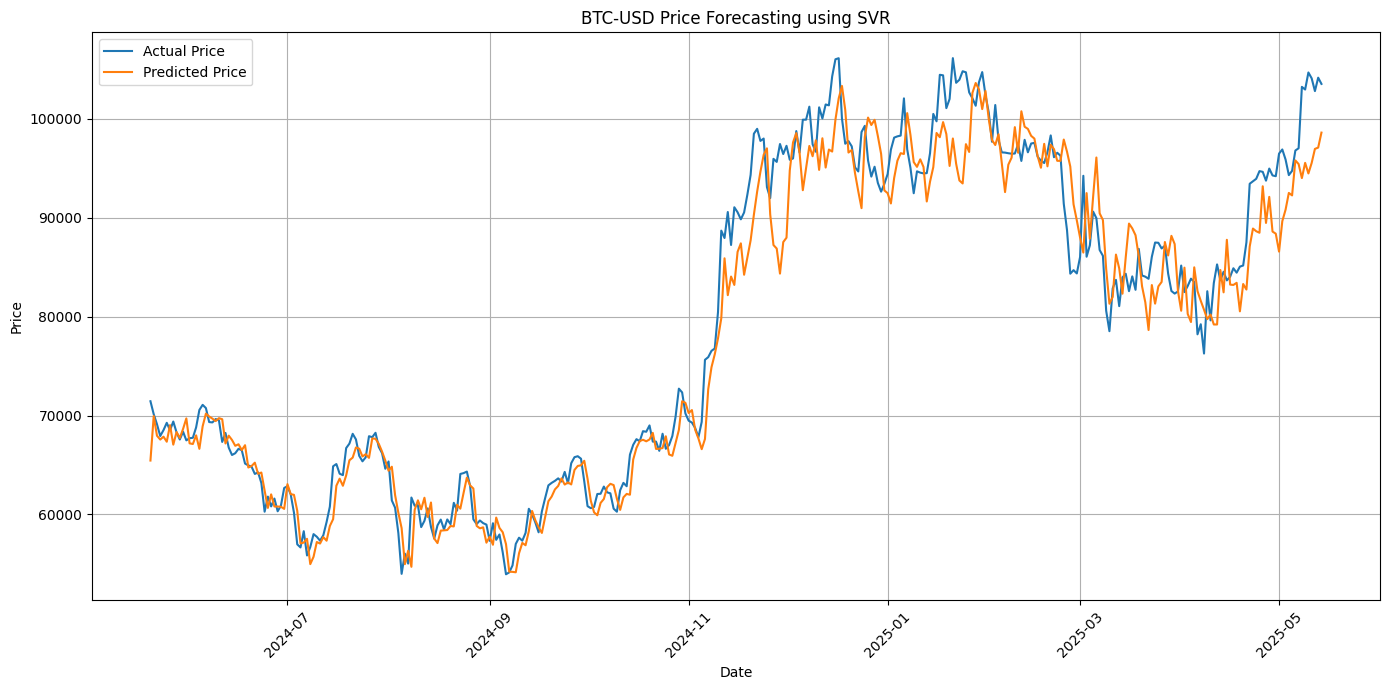

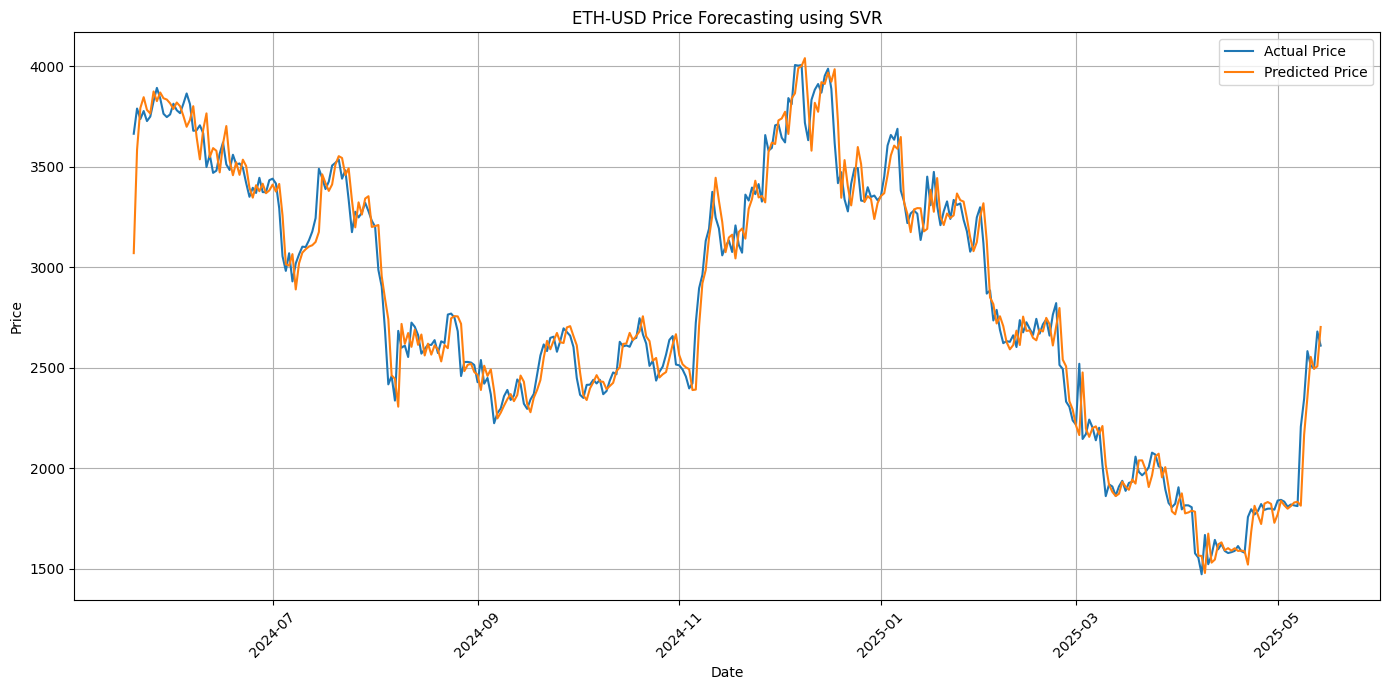

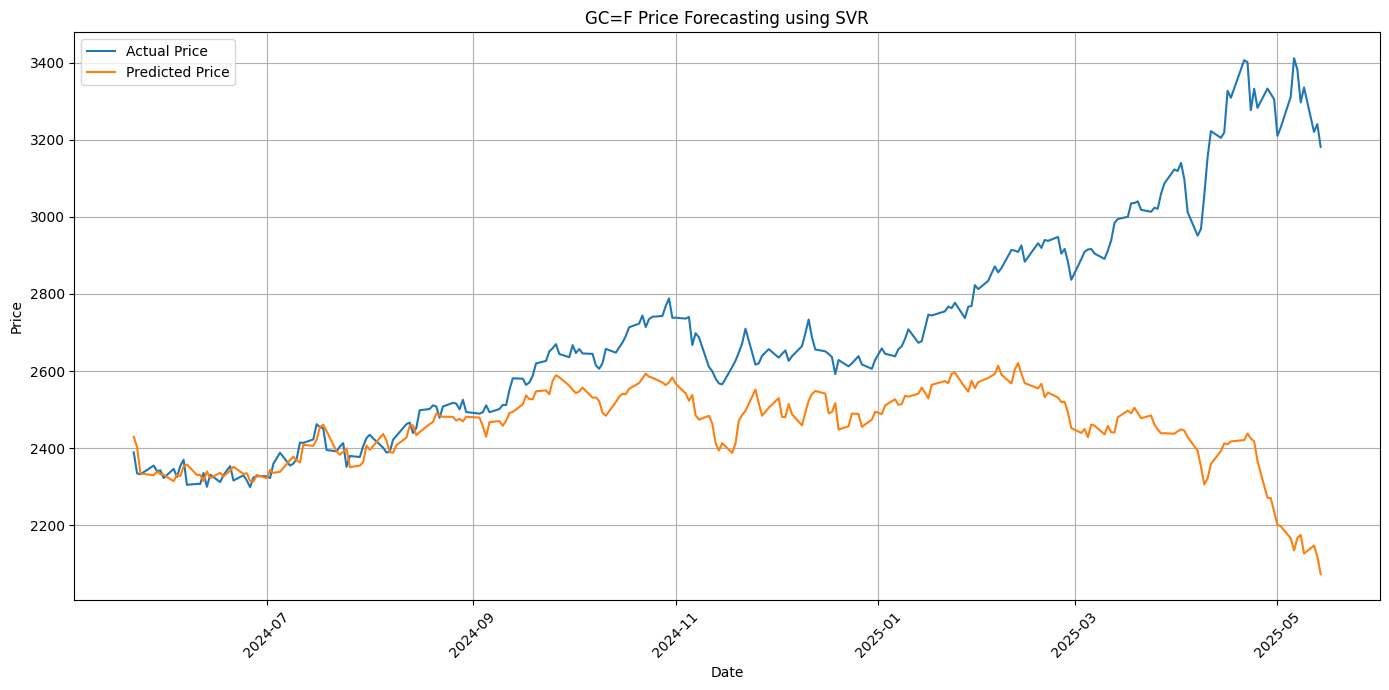

In [50]:
results = []
for symbol in symbols:

    print(f"\n===== {symbol} =====")

    df = yf.download(
        symbol,
        start="2020-05-15",
        end="2025-05-15",
        interval="1d"
    )

    df.columns = df.columns.get_level_values(0)

    data = df[['Close']].copy()

    scaler = MinMaxScaler(feature_range=(0, 1))

    scaled_data = scaler.fit_transform(data)

    window_size = 30

    X = []
    y = []

    for i in range(window_size, len(scaled_data)):
        X.append(scaled_data[i-window_size:i, 0])
        y.append(scaled_data[i, 0])

    X = np.array(X)
    y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        shuffle=False
    )

    model = SVR(
        kernel='rbf',
        C=100,
        gamma=0.1,
        epsilon=0.01
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    predictions = scaler.inverse_transform(
        predictions.reshape(-1, 1)
    )

    y_test_actual = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    )

    mse = mean_squared_error(
        y_test_actual,
        predictions
    )

    mae = mean_absolute_error(
        y_test_actual,
        predictions
    )

    correct = 0

    for i in range(1, len(y_test_actual)):

        actual_diff = (
            y_test_actual[i] -
            y_test_actual[i - 1]
        )

        pred_diff = (
            predictions[i] -
            y_test_actual[i - 1]
        )

        if actual_diff * pred_diff > 0:
            correct += 1

    dstat = correct / (len(y_test_actual) - 1)

    results.append({
        "Symbol": symbol,
        "MSE": mse,
        "MAE": mae,
        "Dstat": dstat
    })

    print(f"MSE   : {mse:.4f}")
    print(f"MAE   : {mae:.4f}")
    print(f"Dstat : {dstat:.4f}")

    # ambil date setelah sliding window
    dates = data.index[window_size:]
    
    # split date sesuai train/test split
    dates_train = dates[:len(X_train)]
    dates_test = dates[len(X_train):]
    
    plt.figure(figsize=(14, 7))
    
    plt.plot(
        dates_test,
        y_test_actual,
        label='Actual Price'
    )
    
    plt.plot(
        dates_test,
        predictions,
        label='Predicted Price'
    )
    
    plt.title(f'{symbol} Price Forecasting using SVR')
    
    plt.xlabel('Date')
    plt.ylabel('Price')
    
    plt.legend()
    plt.grid(True)
    
    plt.xticks(rotation=45)
    
    plt.tight_layout()